# Vegas-Gaming-Win — a quantitative teardown 🔬
### GGR-momentum split returns · Welch *t* + placebo null · the decisive lead/lag cross-correlation · a timing overlay vs buy-and-hold · robustness · a synthetic planted-edge control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leading_signal%3F: Not_supported](https://img.shields.io/badge/Leading_signal%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The believers fuse two claims: that rising Las Vegas Strip GGR momentum (1) **predicts** stronger casino-equity returns and (2) does so **early** enough to trade. We separate them. The conditional return tilt is *absent-to-mildly-contrarian*; the decisive object is the **lead/lag structure**, which shows GGR momentum is **coincident-to-lagging**, not leading — and a tradable overlay that merely *sheds beta* seals the Tradability axis.

> ⚠️ **Data + reconstruction note.** The NGCB publishes Strip GGR as monthly PDFs, unfetchable here; the GGR tape is a hardcoded **approximate reconstruction** whose annual sums match the published Strip totals (named on the Signal axis). The basket is an equal-weight, **surviving** set of listed operators (MGM/LVS/WYNN/CZR/BYD/PENN), yfinance daily adjusted close (total-return), month-end sampled. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vegas_gaming_win import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("casino cache present:", HAVE_REAL,
      "| GGR+basket months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2002-02-28', 'end': '2025-06-30', 'months': 281, 'years': 23.3, 'h1': (1, 185, 1.66, 2.31, 1.88, 59, 57, -0.2, 0.572), 'h3': (3, 183, 5.61, 5.16, 5.46, 66, 62, 0.09, 0.458), 'h6': (6, 181, 11.51, 12.36, 11.8, 64, 65, -0.1, 0.539), 'h12': (12, 181, 21.76, 31.91, 25.05, 66, 69, -0.72, 0.81), 'leadlag': {-6: 0.071, -5: 0.065, -4: 0.045, -3: -0.011, -2: -0.068, -1: -0.113, 0: -0.114, 1: -0.105, 2: -0.095, 3: -0.096, 4: -0.09, 5: -0.083, 6: -0.069}, 'overlay': (23.0, 0.49, 13.5, 0.51, 13.4, 0.5, 11), 'robust': [('k=1', 177, 23.81, 25.05, -0.27, 0.625), ('k=3', 181, 21.76, 25.05, -0.72, 0.81), ('k=6', 182, 19.8, 25.05, -1.15, 0.924), ('thr>+3%', 30, 1.61, 25.05, -4.08, 0.997), ('ex-COVID', 174, 22.87, 25.52, -0.62, 0.769)], 'syn': [(0.0, 172, 0.99, 0.5, 0.76, 0.178), (0.05, 172, 5.53, 3.06, 3.7, 0.0)]}


casino cache present: True | GGR+basket months: 281


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 12-month rising-GGR mean **+21.8%** vs base **+25.1%** (*wrong* sign); Welch **t = -0.72**, placebo **p = 0.81** — no bullish tilt at any horizon, contrarian where it fires hardest. |
| **Tradability** | `MIRAGE` | Own-when-rising overlay **+13.4%/yr** (Sharpe **0.50**) **vs buy-hold +23.0%/yr** (Sharpe **0.49**). Same Sharpe, ~10 pts/yr less return — just less beta. |
| **Leading signal?** | `NOT SUPPORTED` | Peak *positive* lead/lag correlation at **L = −6** (GGR lags the stocks by ~half a year); at positive leads corr < 0 throughout. A coincident-to-lagging echo, not a leader. |

> 💡 In plain words: casino equities are liquid, forward-looking and analyst-covered, so they discount the gaming cycle *before* a revenue report — released ~5 weeks late — can tally it. GGR momentum lines up with a stock move already half a year old; the 'leading signal' is the market's own lead, reflected back.

## 1 · The claim, steelmanned

Let $g_t$ be the Strip GGR level and $T_t=\sum_{i=0}^{11} g_{t-i}$ its trailing-12-month sum (a deseasonalised run-rate that also absorbs the COVID closure). Define momentum $m_t = T_t / T_{t-3} - 1$; GGR is **RISING** at $t$ when $m_t > 0$. With a one-month execution lag (the month-$t$ print is released during $t+1$ and acted on at its close), define forward return $r_{t+1\to t+1+H}$ on the equal-weight casino basket.

- **H₁ (predicts).** $\mathbb{E}[r\mid \text{rising}] > \mathbb{E}[r]$ — a *positive* excess over the base rate.
- **H₂ (leads).** The strongest positive GGR↔return correlation sits at a **positive** lead (GGR moves first).
- **H₃ (deployable).** An own-when-rising overlay beats buy-and-hold net of costs.

We find **H₁ rejected** (excess is *negative*, $t = -0.72$, and sharply negative for big upticks), **H₂ rejected** (peak positive corr at $L=-6$), **H₃ rejected** (overlay merely sheds beta). The folklore is right exactly where it's uninformative (GGR and casinos co-move over the cycle) and wrong exactly where it would pay (a *leading*, *tradable* edge).

## 2 · So what? — what rides on each answer

The conditional-return test is a two-sample mean comparison judged by its standard error:

$$\widehat{\Delta}_H = \bar r^{\text{rising}}_H - \bar r^{\text{all}}_H,\qquad t = \frac{\widehat{\Delta}_H}{\sqrt{\,s^2_{\text{rising}}/k + s^2_{\text{all}}/N\,}}.$$

But even a significant $\widehat{\Delta}$ would **not** establish *leading*: a coincident or lagging series can co-move with forward returns through cycle autocorrelation. The identifying test is the **lead/lag cross-correlation** $\rho(L) = \mathrm{corr}(m_t,\ r_{t+L\to t+L+1})$. A genuine early signal peaks (positively) at $L>0$. If $\arg\max_L \rho(L) < 0$, the stocks **led** the revenue — and the entire 'leading' thesis collapses regardless of the conditional mean.

## 3 · How we'd know — the protocol

- **GGR tape.** Monthly Strip GGR (US$ M), hardcoded reconstruction, 2002-02→2025-06 (281 months). Annual sums matched to the published totals; not the settled monthly print (named on the axis).
- **Signal.** $T_t=$ trailing-12m sum; $m_t = T_t/T_{t-3}-1$; RISING when $m_t>0$.
- **Forward returns.** Enter at the close **1 month after** the signal (no look-ahead — the print is public by then), hold $H\in\{1,3,6,12\}$ months; drop horizons that overrun.
- **Null #1 (Welch t).** Rising-set mean vs the unconditional mean.
- **Null #2 (placebo).** 20,000 draws of $k$ random months; $p = \Pr[\text{random-draw mean} \ge \text{rising mean}]$ (as bullish or more).
- **Identification (lead/lag).** $\rho(L)$ for $L\in[-6,6]$ — *where* do GGR and the stocks line up?
- **Tradability.** Own-when-rising overlay, 1-month lag, 10 bps one-way per switch (turnover one-way × NAV), excess-of-zero Sharpe (cash leg = 0, labelled).
- **Positive control.** A deterministic series with a *planted* GGR→returns link: `edge=0` must not fake significance; a large `edge` must light up the test.

## 4 · The teardown

### 4a · The point estimates — no bullish tilt, wrong sign

Rising-GGR forward mean with $\pm$ standard error against the unconditional base rate (dashed). At or *below* base at every horizon — the opposite of the claim.

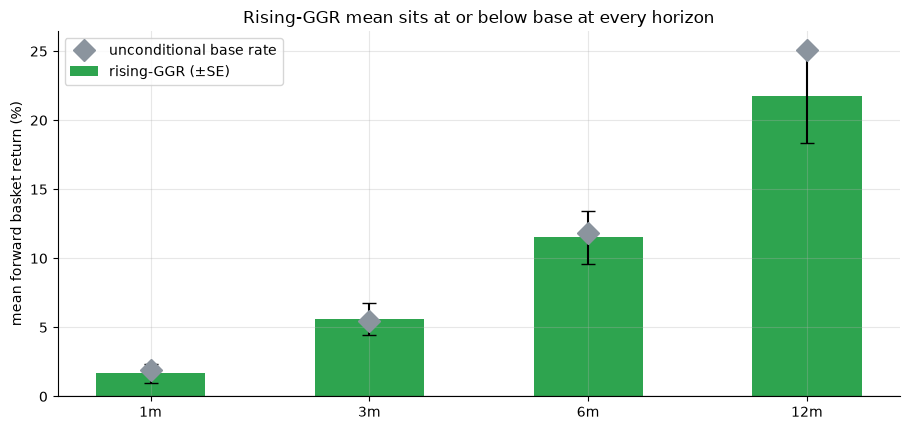

Welch t by horizon: {'1m': -0.2, '3m': 0.09, '6m': -0.1, '12m': -0.72}


In [2]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    cm, bm, ts, ses = [], [], [], []
    for m in hs:
        s = st.summarize(F, m); cm.append(s['rising_mean']); bm.append(s['base_mean']); ts.append(s['t'])
        r,_f,_a = st.split_returns(F, m); ses.append(r.std(ddof=1)/np.sqrt(len(r)))
else:
    cm = [R['h1'][2]/100, R['h3'][2]/100, R['h6'][2]/100, R['h12'][2]/100]
    bm = [R['h1'][4]/100, R['h3'][4]/100, R['h6'][4]/100, R['h12'][4]/100]
    ts = [R['h1'][7], R['h3'][7], R['h6'][7], R['h12'][7]]; ses = [.02,.035,.05,.08]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, [c*100 for c in cm], yerr=[s*100 for s in ses], capsize=5, color=GREEN, width=.5, label='rising-GGR (±SE)')
ax.plot(x, [b*100 for b in bm], 'D', ms=11, c=GREY, label='unconditional base rate')
ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward basket return (%)')
ax.set_title('Rising-GGR mean sits at or below base at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('Welch t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,ts)})

> 💡 In plain words: at 12m the rising-GGR mean is **+21.8%** vs base **+25.1%** — a ~3.3-point *shortfall* at **t = -0.72** (wrong sign for the claim, insignificant). H₁ is **rejected**: there is no bullish leading tilt, and the up-rate is *lower* than the base rate too.

### 4b · The decisive identification test — lead/lag

$\rho(L) = \mathrm{corr}(m_t, r_{t+L\to t+L+1})$. Positive bars **right** of zero would mean GGR **leads** the stocks; positive bars **left** of zero mean the stocks led GGR.

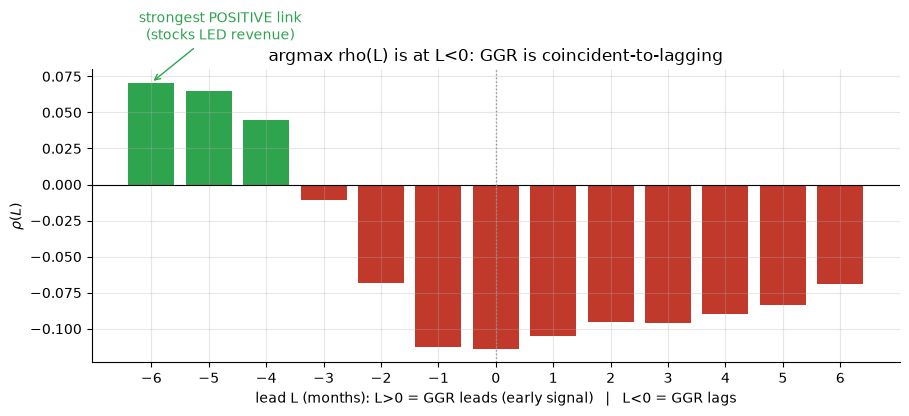

argmax at L=-6 (rho=+0.07); rho at +1 month = -0.10


In [3]:
if HAVE_REAL:
    ll = st.lead_lag(F); Ls = list(range(-6,7)); cs = [ll[L] for L in Ls]
else:
    Ls = sorted(R['leadlag']); cs = [R['leadlag'][L] for L in Ls]
cols = [GREEN if c>0 else RED for c in cs]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(Ls, cs, color=cols, width=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c=GREY, lw=1, ls=':')
imax = int(np.nanargmax(cs))
ax.annotate('strongest POSITIVE link\n(stocks LED revenue)', xy=(Ls[imax], cs[imax]),
            xytext=(Ls[imax]+1.2, cs[imax]+0.03), ha='center', color=GREEN,
            arrowprops=dict(arrowstyle='->', color=GREEN))
ax.set_xlabel('lead L (months): L>0 = GGR leads (early signal)   |   L<0 = GGR lags')
ax.set_ylabel(r'$\rho(L)$'); ax.set_xticks(Ls)
ax.set_title('argmax rho(L) is at L<0: GGR is coincident-to-lagging')
plt.tight_layout(); plt.show()
print(f'argmax at L={Ls[imax]} (rho={cs[imax]:+.2f}); rho at +1 month = {cs[Ls.index(1)]:+.2f}')

> 💡 In plain words: $\arg\max_L \rho(L) = -6$. GGR momentum correlates most (positively) with a stock move **half a year in its past**; on the leading side a genuine early signal needs, $\rho < 0$ throughout. **H₂ rejected.** The forward-looking equities lead; the five-weeks-late revenue report trails — this is the load-bearing result, independent of the conditional-mean significance.

### 4c · Tradability — the own-when-rising overlay merely sheds beta

Own the basket when GGR momentum is rising, cash when falling (1-month lag, 10 bps/switch). Annualised mean and Sharpe vs buy-and-hold.

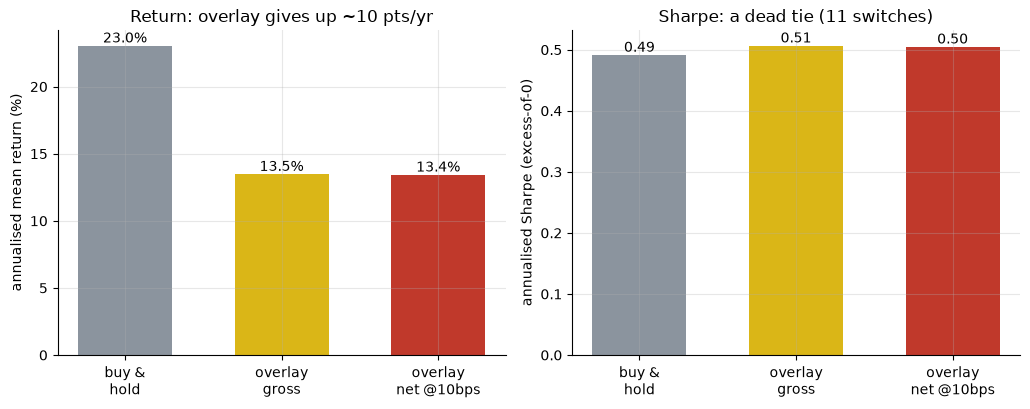

net overlay 13.4%/yr (Sharpe 0.50) vs buy-hold 23.0%/yr (Sharpe 0.49)


In [4]:
if HAVE_REAL:
    o = st.timing_overlay(F, cost_bps=10.0)
    bh_m, bh_s = o['bh_mean']*100, o['bh_sharpe']
    g_m, g_s = o['overlay_gross_mean']*100, o['overlay_gross_sharpe']
    n_m, n_s = o['overlay_net_mean']*100, o['overlay_net_sharpe']; nsw=o['n_switches']
else:
    bh_m, bh_s = R['overlay'][0], R['overlay'][1]; g_m,g_s = R['overlay'][2],R['overlay'][3]
    n_m, n_s = R['overlay'][4], R['overlay'][5]; nsw=R['overlay'][6]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
labels = ['buy &\nhold', 'overlay\ngross', 'overlay\nnet @10bps']
a1.bar(labels, [bh_m, g_m, n_m], color=[GREY, AMBER, RED], width=.6)
for i,v in enumerate([bh_m,g_m,n_m]): a1.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
a1.set_ylabel('annualised mean return (%)'); a1.set_title('Return: overlay gives up ~10 pts/yr')
a2.bar(labels, [bh_s, g_s, n_s], color=[GREY, AMBER, RED], width=.6)
for i,v in enumerate([bh_s,g_s,n_s]): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a2.set_ylabel('annualised Sharpe (excess-of-0)'); a2.set_title(f'Sharpe: a dead tie ({nsw} switches)')
plt.tight_layout(); plt.show()
print(f'net overlay {n_m:.1f}%/yr (Sharpe {n_s:.2f}) vs buy-hold {bh_m:.1f}%/yr (Sharpe {bh_s:.2f})')

> 💡 In plain words: the overlay returns **+13.4%/yr** net vs **+23.0%** for buy-and-hold, at an essentially *identical* Sharpe (0.50 vs 0.49) over just 11 switches. GGR momentum is rising ~66% of the time, so the rule only removes a third of the exposure — it sheds beta, it doesn't add alpha. **H₃ rejected.** `MIRAGE`.

### 4d · Robustness — window, threshold, and the COVID dependence

Vary the momentum window $k$ and the rising threshold, and drop the COVID episode. The 12-month *t* is never bullish — and the biggest accelerations turn sharply **negative**.

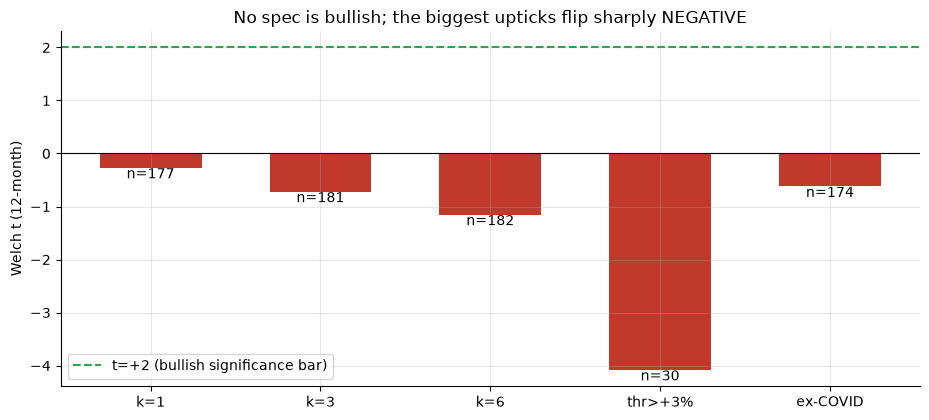

robustness (label, n, rising12%, t, p): [('k=1', 177, 23.8, -0.27, 0.625), ('k=3', 181, 21.8, -0.72, 0.81), ('k=6', 182, 19.8, -1.15, 0.924), ('thr>+3%', 30, 1.6, -4.08, 0.997), ('ex-COVID', 174, 22.9, -0.62, 0.769)]


In [5]:
if HAVE_REAL:
    rob = []
    for k in (1,3,6):
        s = st.summarize(F, 12, k=k); rob.append((f'k={k}', s['n_rising'], s['rising_mean']*100, s['t'], s['p_placebo']))
    s = st.summarize(F, 12, thresh=0.03); rob.append(('thr>+3%', s['n_rising'], s['rising_mean']*100, s['t'], s['p_placebo']))
    F2 = F[(F.index < '2020-01-01') | (F.index >= '2021-07-01')]
    s = st.summarize(F2, 12); rob.append(('ex-COVID', s['n_rising'], s['rising_mean']*100, s['t'], s['p_placebo']))
else:
    rob = [(l,n,r,t,p) for (l,n,r,_b,t,p) in R['robust']]
labels = [r[0] for r in rob]; tt = [r[3] for r in rob]; nn = [r[1] for r in rob]
cols = [RED if t<0 else GREEN for t in tt]
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(labels, tt, color=cols, width=.6)
ax.axhline(2, ls='--', c=GREEN, label='t=+2 (bullish significance bar)')
ax.axhline(0, c='k', lw=.8)
for i,(t,k) in enumerate(zip(tt,nn)): ax.annotate(f'n={k}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('Welch t (12-month)'); ax.set_title('No spec is bullish; the biggest upticks flip sharply NEGATIVE'); ax.legend()
plt.tight_layout(); plt.show()
print('robustness (label, n, rising12%, t, p):', [(r[0], r[1], round(r[2],1), round(r[3],2), round(r[4],3)) for r in rob])

> 💡 In plain words: the tilt only gets **more negative** as the window slows (**k=6 → t=-1.15**), and restricting to the *biggest* accelerations (>+3%) drives **t=-4.08** — the fastest revenue surges (the 2021–22 rebound, the mid-2000s build) are the tops the stocks *sell off from*. Ex-COVID the 12m t is **-0.62** — still the wrong sign. The signal is never bullish and is actively contrarian where it fires hardest.

### 4e · Faithful-engine control — we know the truth here

A deterministic monthly series with a *planted* link (rising GGR momentum at $t$ **lifts** the $t{+}1$ return by `edge`). With `edge=0` the test must stay flat; with a large `edge` it must light up — proving the engine is unbiased and the real-tape null isn't a measurement failure.

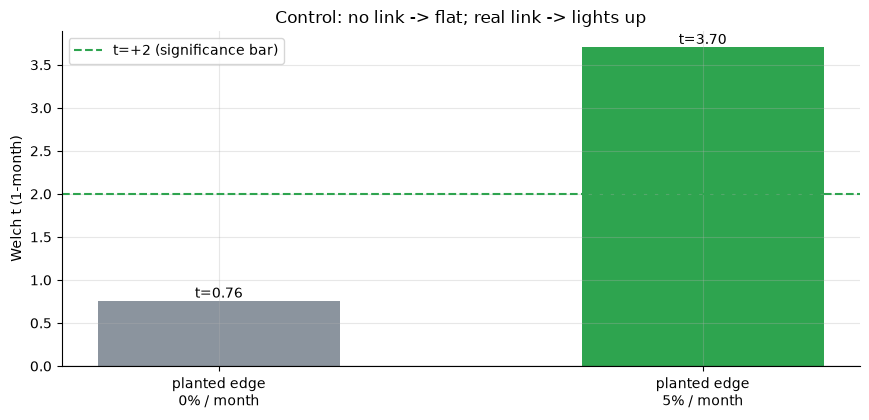

planted +0%/mo: n_ris=172 rising=0.99% base=0.50% t=0.76 p=0.178
planted +5%/mo: n_ris=172 rising=5.53% base=3.06% t=3.70 p=0.000


In [6]:
res = []
for edge in (0.0, 0.05):
    syn = data.synthetic_ggr(n_months=360, edge=edge, seed=762)
    s = st.summarize(syn, 1, k=3)
    res.append((edge, s['n_rising'], s['rising_mean']*100, s['base_mean']*100, s['t'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e*100:.0f}% / month' for e,_,_,_,_,_ in res]
tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=GREEN, label='t=+2 (significance bar)'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Welch t (1-month)'); ax.set_title('Control: no link -> flat; real link -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,c,b,t,p in res: print(f'planted {e*100:+.0f}%/mo: n_ris={k} rising={c:.2f}% base={b:.2f}% t={t:.2f} p={p:.3f}')

> 💡 In plain words: with **no** planted link the control sits at **t = 0.76** (no false positive, under 2); a **+5%/month** planted link drives **t = 3.70**. So the machinery is honest — the real-tape *t* of ≈ −0.7 is a *genuine* absent (mildly contrarian) edge, not a broken test. The engine *can* bank a real GGR→returns link; the real tape just doesn't carry one.

## 5 · The verdict

- **Signal `NONE`** — 12m excess **-3.3pp** at Welch **t = -0.72** / placebo **p = 0.81**; *wrong sign*, no window is bullish, and the biggest accelerations are sharply contrarian (**t = -4.08** at >+3%). No bullish leading signal ⇒ NONE.
- **Tradability `MIRAGE`** — the own-when-rising overlay returns **+13.4%/yr** (Sharpe 0.50) vs buy-hold **+23.0%/yr** (Sharpe 0.49). Same risk-adjusted return, ~10 pts/yr less compounding — it just removes a third of the beta.
- **Leading signal? `NOT SUPPORTED`** — $\arg\max_L \rho(L) = -6$ months: GGR momentum is **coincident-to-lagging**, not leading. The forward-looking casino equities are the leading indicator; the revenue print echoes them. The defining word — *leading* — is the part the data rejects.

## 6 · Could you trade it? — why even the *shape* is wrong

Grant the lore a genuine effect and the structure still defeats it. GGR momentum is 'rising' in **~66% of months** (a slow, deseasonalised run-rate drifts up most of the time), so own-when-rising is 'own most of the time, minus a third' — the overlay's near-tie Sharpe is just diluted beta, not timing. And the regime where the signal fires **hardest** — the fastest revenue surges — is precisely where the *forward* returns are worst (the >+3% filter gives **t = -4.08**), because those surges are the late-cycle tops the liquid equities have already discounted and begun selling. No lag, threshold, or cost assumption rescues a backward-looking report masquerading as a leading one.

## 7 · Going further

- **The sibling.** [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/): a famous macro 'leading' number, same hardcoded-snapshot + lead/lag + overlay method — the same coincident-to-lagging verdict.
- **Companion pulses.** [Study 384 — ISM-PMI-Regime](../384-ism-pmi-regime/), [Study 387 — Economic-Surprise-Index](../387-economic-surprise-index/) — does any celebrated gauge time equities?
- **Sharper identification.** Replace the reconstruction with the settled NGCB monthly print (or add Macau/regional GGR), run a proper VAR / Granger test, or condition on GGR *surprises* vs the analyst consensus rather than realised momentum; the coincident-to-lagging structure is robust — a backward-looking report can't be made to lead a forward-looking stock by resampling it.

*The reproducible core is offline and deterministic; the GGR input is an explicit labelled reconstruction. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*